# **Reconhecimento Facial**

In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix


In [2]:
BASE_DIR = Path.cwd().parent
imagens_treino = BASE_DIR / "data" / "yalefaces" / "train"
imagens_teste = BASE_DIR / "data" / "yalefaces" / "test"

## Pré-processamento das imagens

In [3]:
print(os.listdir(imagens_treino))

['subject08.wink.gif', 'subject09.wink.gif', 'subject02.glasses.gif', 'subject15.happy.gif', 'subject06.noglasses.gif', 'subject11.noglasses.gif', 'subject03.sad.gif', 'subject05.normal.gif', 'subject14.leftlight.gif', 'subject15.noglasses.gif', 'subject02.noglasses.gif', 'subject06.rightlight.gif', 'subject13.rightlight.gif', 'subject06.centerlight.gif', 'subject10.leftlight.gif', 'subject09.centerlight.gif', 'subject02.wink.gif', 'subject03.wink.gif', 'subject11.sleepy.gif', 'subject14.rightlight.gif', 'subject01.rightlight.gif', 'subject08.sleepy.gif', 'subject14.sleepy.gif', 'subject12.glasses.gif', 'subject13.happy.gif', 'subject11.normal.gif', 'subject02.sad.gif', 'subject12.sad.gif', 'subject15.wink.gif', 'subject14.wink.gif', 'subject08.surprised.gif', 'subject12.noglasses.gif', 'subject05.noglasses.gif', 'subject07.glasses.gif', 'subject07.rightlight.gif', 'subject01.noglasses.gif', 'subject13.leftlight.gif', 'subject10.rightlight.gif', 'subject05.rightlight.gif', 'subject06.s

In [4]:
def get_image_data(path_img):
    paths = [os.path.join(path_img, f) for f in os.listdir(path_img)]
    faces = []
    ids = []
    for path in paths:
        imagem = Image.open(path).convert('L')
        imagem_np = np.array(imagem, 'uint8')
        id = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))
        ids.append(id)
        faces.append(imagem_np)
    return np.array(ids), faces

In [5]:
ids, faces = get_image_data(imagens_treino)
len(ids), len(faces)

(135, 135)

## Treinamento do classificador LBPH

In [6]:
lbph_classifier = cv2.face.LBPHFaceRecognizer_create(radius=4, neighbors=14, grid_x=9, grid_y=9)
lbph_classifier.train(faces, ids)
lbph_classifier.write('lbph_classifier.yml')

## Reconhecimento de faces

In [7]:
lbph_face_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_face_classifier.read('./lbph_classifier.yml')

In [8]:
imagem_teste = '../data/yalefaces/test/subject10.sad.gif'
imagem = Image.open(imagem_teste).convert('L')
imagem_np = np.array(imagem, 'uint8')
imagem_np.shape

(243, 320)

In [9]:
previsao = lbph_face_classifier.predict(imagem_np)
previsao

(10, 36.84750735484425)

In [10]:
saida_esperada = int(os.path.split(imagem_teste)[1].split('.')[0].replace('subject', ''))
saida_esperada

10

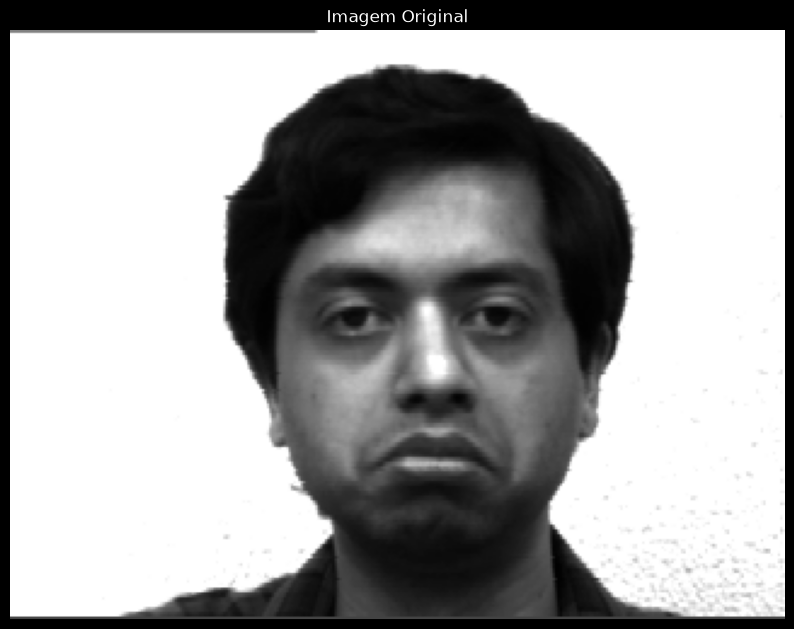

In [11]:
results = (f'Pred: {previsao[0]}\nExp: {saida_esperada}')
plt.figure(figsize=(10,10))
plt.title('Imagem Original')
imgRGB = cv2.cvtColor(imagem_np, cv2.COLOR_BGR2RGB)
plt.imshow(imgRGB)
plt.text(3.0, 30.0, results)
plt.axis('off')
plt.show()

## Avaliação do Classificador

In [12]:
paths = [os.path.join(imagens_teste, f) for f in os.listdir(imagens_teste)]
previsoes = []
saidas_esperadas = []
for path in paths:
    imagem = Image.open(path).convert('L')
    imagem_np = np.array(imagem, 'uint8')
    previsao, _ = lbph_face_classifier.predict(imagem_np)
    saida_esperada = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))
    previsoes.append(previsao)
    saidas_esperadas.append(saida_esperada)
print(previsoes)
print(saidas_esperadas)

[13, 1, 3, 9, 7, 8, 4, 14, 7, 4, 7, 4, 5, 12, 4, 9, 13, 10, 11, 6, 5, 4, 4, 14, 11, 15, 3, 12, 14, 12]
[13, 1, 3, 7, 9, 8, 10, 14, 15, 8, 7, 1, 5, 12, 4, 9, 13, 10, 11, 6, 5, 2, 4, 14, 11, 15, 3, 12, 6, 2]


In [13]:
previsoes = np.array(previsoes)
saidas_esperadas = np.array(saidas_esperadas)
previsoes, saidas_esperadas

(array([13,  1,  3,  9,  7,  8,  4, 14,  7,  4,  7,  4,  5, 12,  4,  9, 13,
        10, 11,  6,  5,  4,  4, 14, 11, 15,  3, 12, 14, 12]),
 array([13,  1,  3,  7,  9,  8, 10, 14, 15,  8,  7,  1,  5, 12,  4,  9, 13,
        10, 11,  6,  5,  2,  4, 14, 11, 15,  3, 12,  6,  2]))

In [14]:
accuracy_score(saidas_esperadas, previsoes)

0.7

In [15]:
cm = confusion_matrix(saidas_esperadas, previsoes)
cm

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1]])

<Axes: >

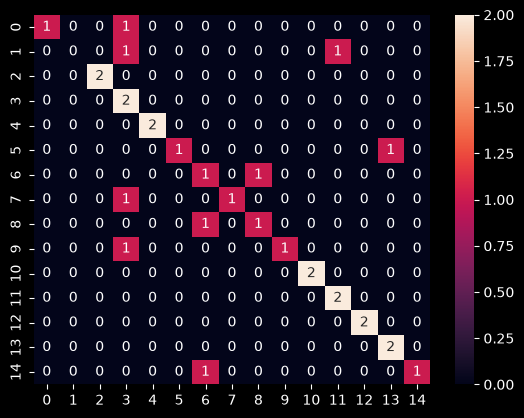

In [16]:
sns.heatmap(cm, annot=True)

# Dlib

In [17]:
import dlib

### Detecção de pontos faciais

In [18]:
pesos = BASE_DIR / "data" / "Weights"
imagens = BASE_DIR / "data" / "Images"

In [19]:
detector_face = dlib.get_frontal_face_detector()
detector_pontos = dlib.shape_predictor(os.path.join(pesos, 'shape_predictor_68_face_landmarks.dat'))

In [20]:
imagem = cv2.imread(os.path.join(imagens, 'people2.jpg'))

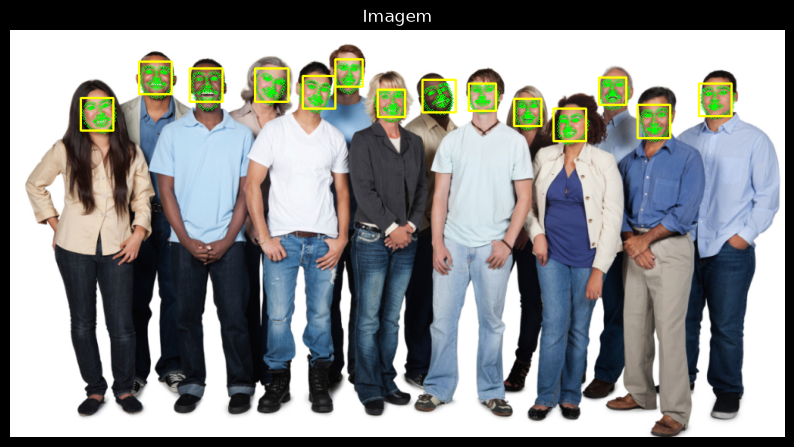

In [21]:
deteccoes = detector_face(imagem, 1)
for face in deteccoes:
    pontos = detector_pontos(imagem, face)
    for ponto in pontos.parts():
        cv2.circle(imagem, (ponto.x, ponto.y), 2, (0, 255, 0), 1)
    l, t, r, b = face.left(), face.top(), face.right(), face.bottom()
    cv2.rectangle(imagem, (l,t), (r, b), (0,255, 255), 2)
plt.figure(figsize=(10,10))
plt.title('Imagem')
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
plt.imshow(imagem)
plt.axis('off')
plt.show()

### Detecção de descritores Faciais

In [22]:
detector_face = dlib.get_frontal_face_detector()
detector_pontos = dlib.shape_predictor(os.path.join(pesos, 'shape_predictor_68_face_landmarks.dat'))
descritor_facial_extrator = dlib.face_recognition_model_v1(os.path.join(pesos, 'dlib_face_recognition_resnet_model_v1.dat'))

In [23]:
index = {}
idx = 0
descritores_faciais = None

paths = [os.path.join(imagens_treino, f) for f in os.listdir(imagens_treino)]
for path in paths[:5]:
    imagem = Image.open(path).convert('RGB')
    imagem_np = np.array(imagem, 'uint8')
    deteccoes = detector_face(imagem_np, 1)
    for face in deteccoes:
        l, t, r, b = face.left(), face.top(), face.right(), face.bottom()
        cv2.rectangle(imagem_np, (l, t), (r, b), (255, 0, 0), 2)

        pontos = detector_pontos(imagem_np, face)
        for ponto in pontos.parts():
            cv2.circle(imagem_np, (ponto.x, ponto.y), 2, (0, 255, 0), 1)
        descritor_facial = descritor_facial_extrator.compute_face_descriptor(
            imagem_np, pontos
        )
        descritor_facial = [f for f in descritor_facial]
        descritor_facial = np.asarray(descritor_facial, dtype=np.float64)
        descritor_facial = descritor_facial[np.newaxis, :]

        if descritores_faciais is None:
            descritores_faciais = descritor_facial
        else:
            descritores_faciais = np.concatenate((descritores_faciais, descritor_facial), axis=0)
    index[idx] = path
    idx += 1
    # plt.figure(figsize=(10,10))
    # plt.title('Imagem')
    # plt.imshow(imagem_np)
    # plt.axis('off')
    # plt.show()

In [24]:
len(index)

5

### Cálculo da distância entre as faces

### Detecção de faces com Dlib

### Exercício